# Deep Learning Assignment 1 | An early warning for bank deposits

**Will Moore · Due September 20, 2026**

## Business question

**Can the latest available quarterly report flag which FDIC insured banks may lose domestic deposits in the next quarter, and how large a decline might be?** A risk or treasury analyst needs to choose which banks to investigate before the next balance is reported. This notebook asks two linked questions: **Will deposits fall? If they do, how much?** Those answers support a ranked review list.

**Aim of this assignment.** I use quarterly FDIC bank data to define next quarter deposit decline, complete an exploratory data analysis, prepare a chronological train/validation/test split, and compare a two-head neural network with simple baselines. I evaluate the chance of decline, the size of positive declines, and the dollar coverage of a ranked review list. The outcome is a change in reported balance. It does not identify customer withdrawals, bank failure, or a bank run.

**Route:** source audit → deposit trail → predictors → chance and severity heads → held out review list. Each stop asks one question and leaves a visible answer.

## Data | The deposit trail

**Source.** The [FDIC BankFind Suite financial API](https://api.fdic.gov/banks/docs/) supplies one record per FDIC certificate and reporting quarter. The supplied file covers 2020 Q1 through 2024 Q4. The [FDIC field definitions](https://api.fdic.gov/banks/docs/risview_properties.yaml) define `DEPDOM` as deposits held in domestic offices; reported financial amounts are in **thousands of US dollars**. I convert deposit declines to **millions of dollars** for charts and scoring. `CERT` identifies a bank; `REPDTE` identifies the quarter.

**Reproduction.** The accompanying `data/fdic_financials_2020_2024.csv` is part of the submission. Run the cells in order from the project folder. `download_fdic.py` documents the exact API extraction but is not needed to execute this notebook. The model uses TensorFlow, Pandas, scikit learn, NumPy, and Matplotlib.

**Evidence boundary.** A balance decline can reflect ordinary customer activity, corporate actions, reporting changes, or other causes. FDIC certificate continuity is a practical matching rule, not a complete merger history. Banks that disappear before a next report have no measured next quarter target here.

### 1. Can we trust the rows and units?

The first audit checks the bank quarter key, date coverage, field types, and missing values. The preview shows only the columns used to establish that grain.

In [1]:
# Imports and reproducible setup
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.metrics import brier_score_loss, mean_absolute_error, median_absolute_error, roc_auc_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from wm_notecards import WMTheme, init_notebook
from wm_notecards.cards import question_card, takeaway_card, wm_check_card, wm_formula_card
from wm_notecards.tables import wm_render_styler

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
theme = WMTheme.light()
init_notebook(expand_colab_outputs=True)
RUN_ON_GPU = False  # Small tabular MLP: CPU is usually simpler and faster to rerun.
if not RUN_ON_GPU:
    tf.config.set_visible_devices([], "GPU")
print("TensorFlow GPU enabled:", bool(tf.config.get_visible_devices("GPU")))
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.18, "font.size": 10})
BLUE, GOLD, INK = theme.accent, "#D99418", theme.text_main

data_path = Path("data/fdic_financials_2020_2024.csv")
if not data_path.is_file():
    raise FileNotFoundError(
        f"Missing {data_path}. Submit the data folder with Assign1.ipynb."
    )
raw = pd.read_csv(data_path)
required = {"REPDTE", "CERT", "NAME", "DEPDOM", "ASSET", "LNLSNET", "CHBAL", "EQ"}
missing_fields = required.difference(raw.columns)
if missing_fields:
    raise ValueError(f"FDIC CSV is missing fields: {sorted(missing_fields)}")
raw["report_date"] = pd.to_datetime(raw["REPDTE"].astype(str), format="%Y%m%d")
assert not raw.duplicated(["CERT", "report_date"]).any(), "Duplicate bank-quarter keys"
assert raw["DEPDOM"].ge(0).all(), "Negative domestic deposits need review"
print(f"{len(raw):,} bank-quarter rows | {raw.CERT.nunique():,} certificates | "
      f"{raw.report_date.min():%Y-%m-%d} through {raw.report_date.max():%Y-%m-%d}")
question_card(
    title="Which banks might show deposit pressure next quarter?",
    theme=theme,
    body="A risk analyst needs a chance, a possible size, and a short review list. First, we check what each FDIC row measures and whether consecutive quarters can be matched.",
    kicker="BUSINESS QUESTION",
    chip_text="START HERE",
)

TensorFlow GPU enabled: False
96,902 bank-quarter rows | 5,237 certificates | 2020-03-31 through 2024-12-31


In [2]:
# Preview the bank-quarter rows and count missing values
display(raw[["CERT", "NAME", "report_date", "DEPDOM", "ASSET"]].head(6)
        .rename(columns={"DEPDOM": "Domestic deposits ($000)",
                         "ASSET": "Assets ($000)"}))
display(pd.DataFrame({"dtype": raw.dtypes.astype(str),
                      "missing_rows": raw.isna().sum(),
                      "missing_percent": 100 * raw.isna().mean()}).round(2))

,CERT,NAME,report_date,Domestic deposits ($000),Assets ($000)
0,10004,ERGO BANK,2020-03-31,77700,95114
1,10011,WOODFORD STATE BANK,2020-03-31,196880,256172
2,10012,PORTAGE COUNTY BANK,2020-03-31,142528,161445
3,10015,SECURITY BANK,2020-03-31,100234,115649
4,10044,NATIONAL EXCHANGE BANK&TRUST,2020-03-31,1614693,2089096
5,10055,FIRST SOUTHERN BANK,2020-03-31,123080,141312


,dtype,missing_rows,missing_percent
REPDTE,int64,0,0.00
CERT,int64,0,0.00
NAME,str,0,0.00
STALP,str,20,0.02
DEPDOM,int64,0,0.00
ASSET,int64,0,0.00
LNLSNET,int64,0,0.00
CHBAL,int64,0,0.00
EQ,float64,340,0.35
report_date,datetime64[us],0,0.00


### 2. How much history and missingness do we have?

These two views separate source coverage from source quality. Bank counts can fall when institutions exit or combine; the line does not identify why.

report_date,2020-03-31,2020-06-30,2020-09-30,2020-12-31,2021-03-31,2021-06-30,2021-09-30,2021-12-31,2022-03-31,2022-06-30,2022-09-30,2022-12-31,2023-03-31,2023-06-30,2023-09-30,2023-12-31,2024-03-31,2024-06-30,2024-09-30,2024-12-31
bank_rows,5182,5131,5098,5067,5044,5015,4979,4904,4861,4838,4813,4773,4740,4714,4686,4658,4640,4610,4589,4560


,missing rows
DEPDOM,0
ASSET,0
LNLSNET,0
CHBAL,0
EQ,340


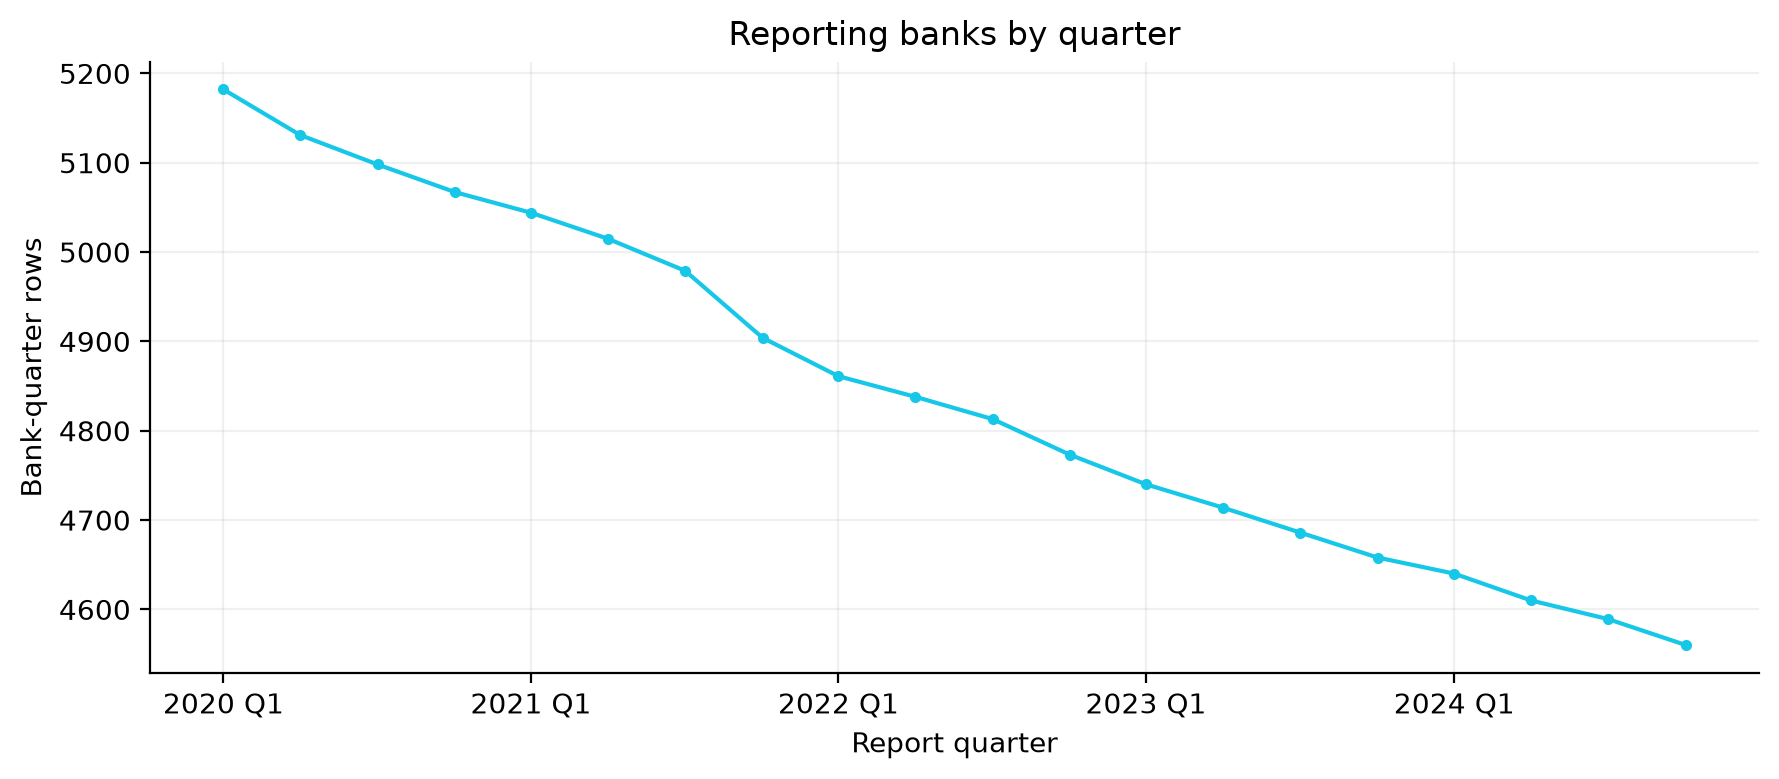

In [3]:
# Check quarter coverage and missing financial fields
coverage = raw.groupby("report_date").size().rename("bank_rows")
missing = raw[["DEPDOM", "ASSET", "LNLSNET", "CHBAL", "EQ"]].isna().sum()
display(coverage.to_frame().T)
display(missing.rename("missing rows").to_frame())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(coverage.index, coverage.values, color=BLUE, marker="o", ms=3)
ax.set(title="Reporting banks by quarter", ylabel="Bank-quarter rows",
       xlabel="Report quarter")
tick_dates = coverage.index[::4]
ax.set_xticks(tick_dates, [f"{d.year} Q{d.quarter}" for d in tick_dates])
plt.tight_layout()
plt.show()
wm_check_card(
    title="The bank-quarter key is clean; equity needs a small repair",
    theme=theme,
    checks=[
        {"label": "One row per certificate and quarter", "status": "PASS",
         "detail": f"{len(raw):,} rows; no duplicate (CERT, date) keys"},
        {"label": "Domestic deposit balances", "status": "PASS",
         "detail": f"{missing['DEPDOM']:,} missing of {len(raw):,} rows"},
        {"label": "Equity field", "status": "CHECK",
         "detail": f"{missing['EQ']:,} missing of {len(raw):,} rows; training-only median imputation follows"},
    ],
    kicker="SOURCE AUDIT",
)

### 3. What exactly counts as runoff?

For bank *i* in quarter *t*, **next quarter runoff ($M) = max(0, domestic deposits at *t* − domestic deposits at *t+1*) / 1,000**. The maximum makes growth equal zero runoff. A pair qualifies only when both reports have the same FDIC certificate and adjacent quarters. I also require a prior adjacent quarter so prior deposit movement can be a predictor, and at least $10 million in current domestic deposits to avoid ratios driven by tiny balances. These rules are visible in the counts below.

The last report, 2024 Q4, has no next quarter in the supplied data. Consequently, the final test uses 2024 Q1 through Q3, with outcomes observed through Q4.

In [4]:
# Show the target definition and dollar unit
wm_formula_card(
    title="The target is a measured balance decline",
    theme=theme,
    items=[{"label": "Next-quarter runoff ($M)",
            "fallback": "max(0, domestic deposits at t − domestic deposits at t+1) / 1,000"}],
    subtitle="FDIC reports balances in $000; dividing by 1,000 gives $M.",
)

In [5]:
# Keep consecutive bank-quarter pairs and show the row counts
bank_rows = raw.sort_values(["CERT", "report_date"]).copy()
bank_rows["quarter_number"] = bank_rows.report_date.dt.to_period("Q").astype("int64")
by_bank = bank_rows.groupby("CERT", sort=False)
bank_rows["prior_quarter"] = by_bank.quarter_number.shift(1)
bank_rows["next_quarter"] = by_bank.quarter_number.shift(-1)
bank_rows["prior_deposits"] = by_bank.DEPDOM.shift(1)
bank_rows["next_deposits"] = by_bank.DEPDOM.shift(-1)
adjacent_prior = bank_rows.quarter_number.sub(bank_rows.prior_quarter).eq(1)
adjacent_next = bank_rows.next_quarter.sub(bank_rows.quarter_number).eq(1)
size_eligible = bank_rows.DEPDOM.ge(10_000)  # FDIC reports $000: $10M minimum
valid_balance = bank_rows.prior_deposits.gt(0) & bank_rows.next_deposits.ge(0)
eligible = adjacent_prior & adjacent_next & size_eligible & valid_balance & bank_rows.ASSET.gt(0)

eligibility_receipt = pd.DataFrame({
    "step": ["Downloaded reports", "Adjacent prior quarter", "Adjacent next quarter",
             "At least $10M in domestic deposits", "All modeling conditions"],
    "rows meeting condition": [len(bank_rows), int(adjacent_prior.sum()),
                               int(adjacent_next.sum()), int(size_eligible.sum()),
                               int(eligible.sum())]
})
display(eligibility_receipt)
model_rows = bank_rows.loc[eligible].copy()
model_rows["runoff_m"] = ((model_rows.DEPDOM - model_rows.next_deposits)
                          .clip(lower=0) / 1_000)
assert model_rows.runoff_m.ge(0).all()

,step,rows meeting condition
0,Downloaded reports,96902
1,Adjacent prior quarter,91665
2,Adjacent next quarter,91665
3,At least $10M in domestic deposits,95089
4,All modeling conditions,84922


### 4. Which dates can teach the model?

The split follows calendar time, as a real forecast would. **Training:** current reports through 2022 Q4. **Validation:** 2023 reports, used for model selection. **Test:** 2024 Q1–Q3 reports, used once after selection. I inspect target relationships below using the training rows only.

In [6]:
train = model_rows.loc[model_rows.report_date.dt.year.le(2022)].copy()
valid = model_rows.loc[model_rows.report_date.dt.year.eq(2023)].copy()
test = model_rows.loc[model_rows.report_date.dt.year.eq(2024)].copy()
assert len(train) and len(valid) and len(test)
assert train.report_date.max() < valid.report_date.min() < test.report_date.min()
split_receipt = pd.DataFrame({
    "split": ["Training", "Validation", "Test"],
    "bank-quarter rows": [len(train), len(valid), len(test)],
    "first current report": [x.report_date.min().date() for x in (train, valid, test)],
    "last current report": [x.report_date.max().date() for x in (train, valid, test)],
})
display(split_receipt)

,split,bank-quarter rows,first current report,last current report
0,Training,53121,2020-06-30,2022-12-31
1,Validation,18321,2023-03-31,2023-12-31
2,Test,13480,2024-03-31,2024-09-30


### 5. How uneven are bank size and runoff?

The training period answers this question. A typical bank and a giant bank occupy very different scales, so log axes reveal the shape without dropping large observations. Zero runoff is shown separately because its logarithm is not defined.

,measure,value
0,Training bank-quarters,"53,121"
1,With next-quarter runoff,"17,809"
2,Runoff share,33.5%
3,Median domestic deposits ($M),261.9
4,Median positive runoff ($M),4.9
5,95th percentile positive runoff ($M),156.5
6,Largest runoff ($M),"76,655.0"


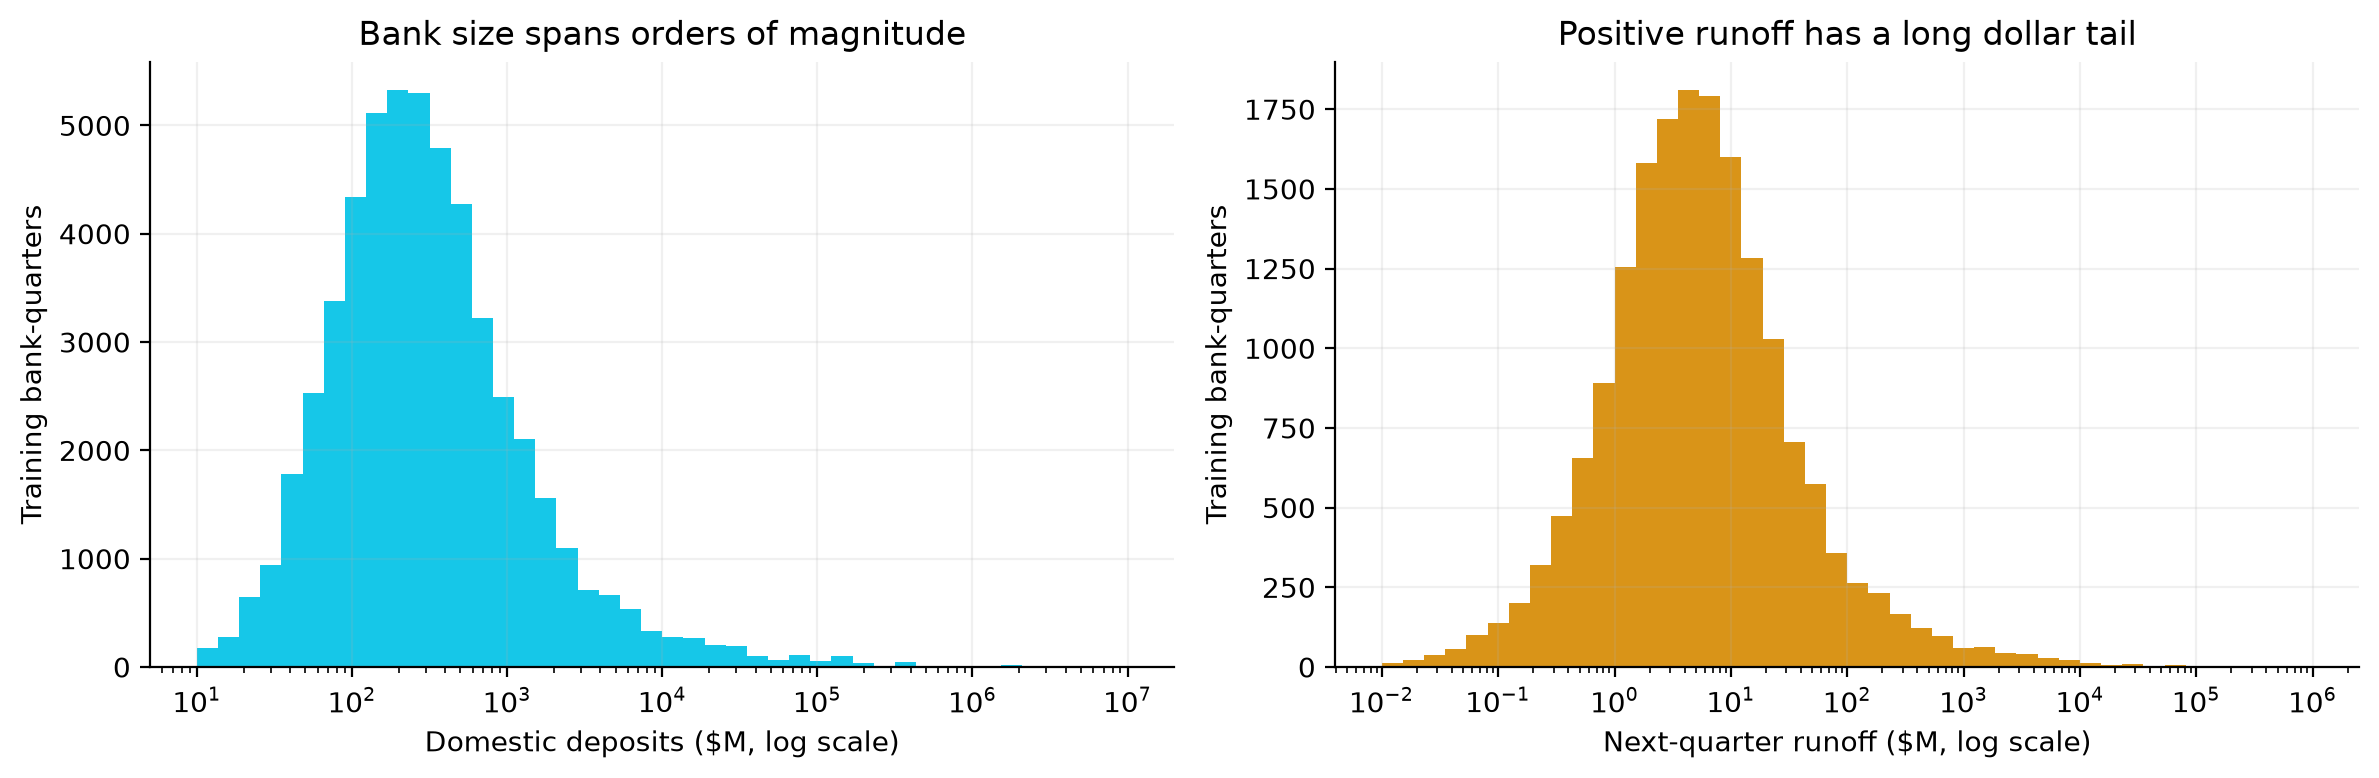

In [7]:
# Describe the size and runoff distributions in training data
positive_train = train.loc[train.runoff_m.gt(0)]
shape_receipt = pd.DataFrame({
    "measure": ["Training bank-quarters", "With next-quarter runoff", "Runoff share",
                "Median domestic deposits ($M)", "Median positive runoff ($M)",
                "95th percentile positive runoff ($M)", "Largest runoff ($M)"],
    "value": [f"{len(train):,}", f"{len(positive_train):,}",
              f"{len(positive_train)/len(train):.1%}",
              f"{train.DEPDOM.median()/1_000:,.1f}",
              f"{positive_train.runoff_m.median():,.1f}",
              f"{positive_train.runoff_m.quantile(.95):,.1f}",
              f"{positive_train.runoff_m.max():,.1f}"]
})
display(shape_receipt)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train.DEPDOM / 1_000, bins=np.logspace(1, 7, 45), color=BLUE)
axes[0].set_xscale("log")
axes[0].set(title="Bank size spans orders of magnitude", xlabel="Domestic deposits ($M, log scale)",
            ylabel="Training bank-quarters")
axes[1].hist(positive_train.runoff_m, bins=np.logspace(-2, 6, 45), color=GOLD)
axes[1].set_xscale("log")
axes[1].set(title="Positive runoff has a long dollar tail",
            xlabel="Next-quarter runoff ($M, log scale)", ylabel="Training bank-quarters")
plt.tight_layout()
plt.show()
takeaway_card(
    title="A typical decline and a giant-bank decline are different problems",
    theme=theme,
    metric=f"{len(positive_train)/len(train):.1%} of training bank-quarters declined",
    body=(f"The median positive decline was ${positive_train.runoff_m.median():,.1f}M, "
          f"while the largest was ${positive_train.runoff_m.max():,.1f}M. "
          "This long tail motivates a log target and both typical-row and dollar-scale error checks."),
    kicker="EDA TAKEAWAY",
)

### 6. Is runoff rare, and does it move over time?

The first chart gives the share of training bank quarters with a decline. The second gives total dollars of decline each quarter. These answer different questions: frequency and dollar exposure. A few very large banks can dominate the dollar line.

,bank_rows,runoff_banks,runoff_m,runoff_share
report_date,,,,
2020-06-30,5006,1632,117342.005,0.326
2020-09-30,4975,909,52658.488,0.183
2020-12-31,4948,419,35258.137,0.085
2021-03-31,4923,1680,102281.012,0.341
2021-06-30,4887,1499,55866.751,0.307
2021-09-30,4816,1114,89939.872,0.231
2021-12-31,4775,1151,133311.467,0.241
2022-03-31,4745,2282,432767.906,0.481
2022-06-30,4718,2342,349531.615,0.496


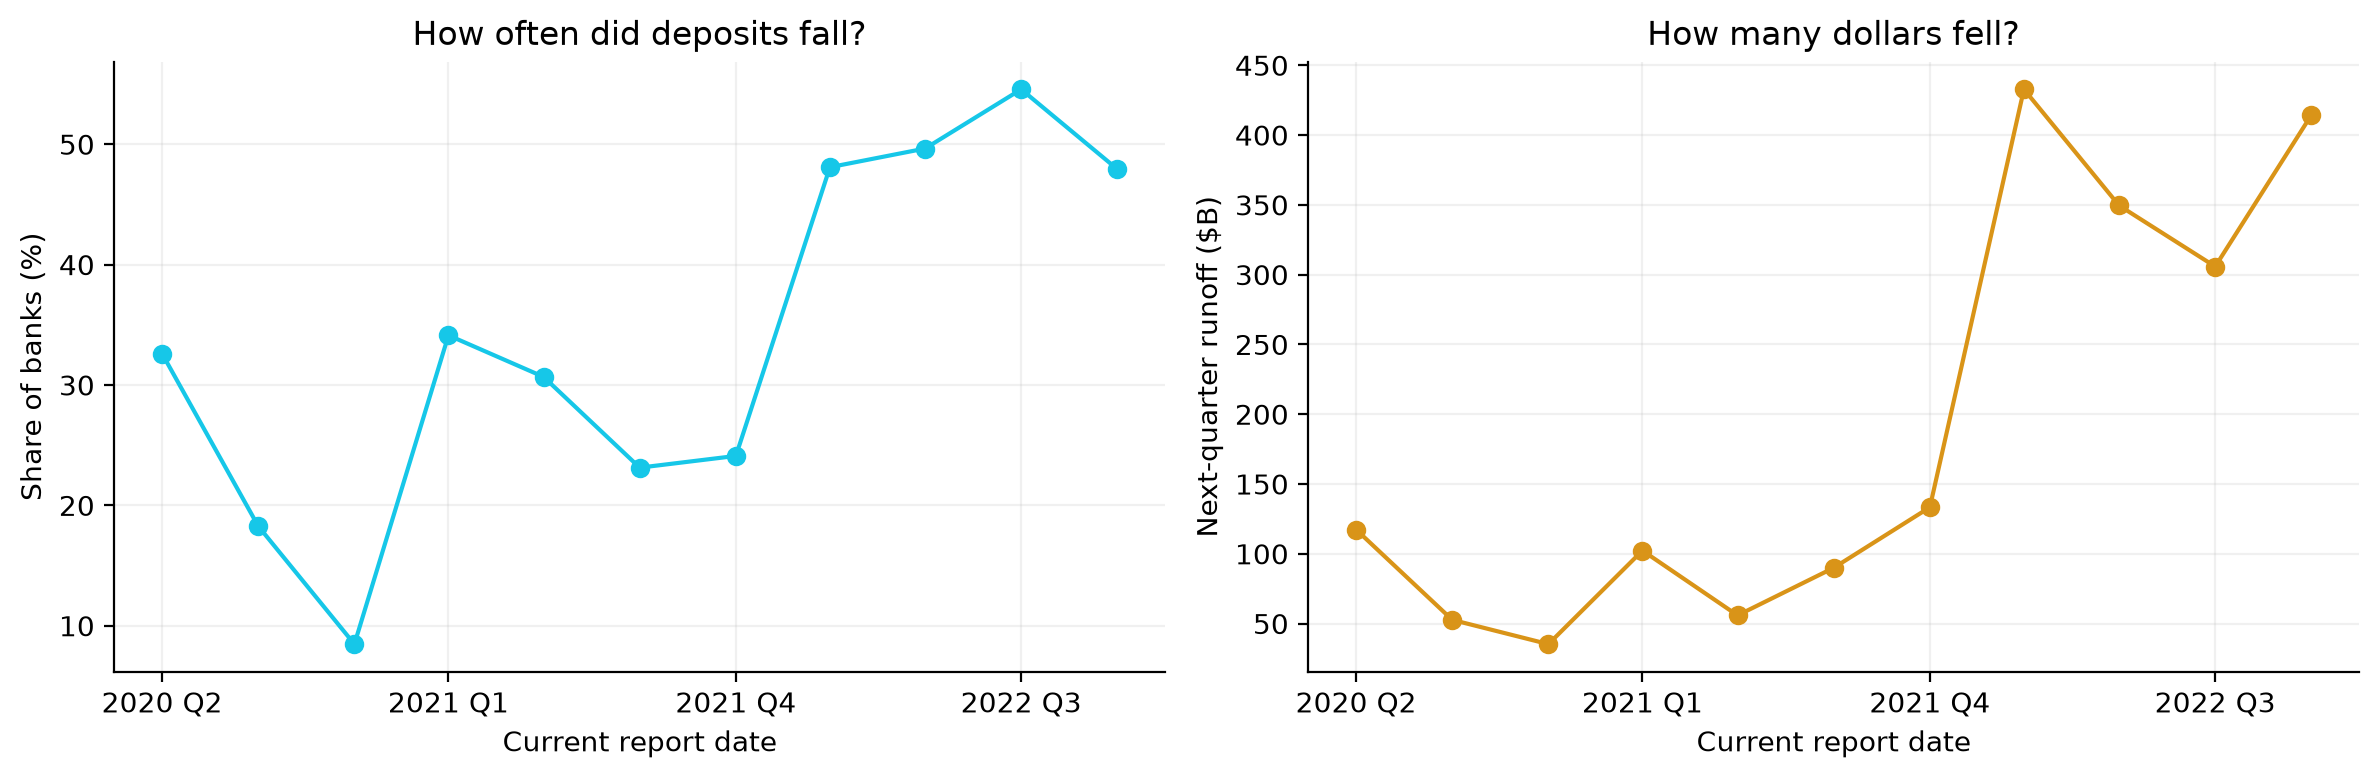

In [8]:
quarterly_train = train.groupby("report_date").agg(
    bank_rows=("CERT", "size"), runoff_banks=("runoff_m", lambda s: int(s.gt(0).sum())),
    runoff_m=("runoff_m", "sum"))
quarterly_train["runoff_share"] = quarterly_train.runoff_banks / quarterly_train.bank_rows
display(quarterly_train.round(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(quarterly_train.index, quarterly_train.runoff_share * 100,
             color=BLUE, marker="o")
axes[0].set(title="How often did deposits fall?", ylabel="Share of banks (%)",
            xlabel="Current report date")
axes[1].plot(quarterly_train.index, quarterly_train.runoff_m / 1_000,
             color=GOLD, marker="o")
axes[1].set(title="How many dollars fell?", ylabel="Next-quarter runoff ($B)",
            xlabel="Current report date")
for ax in axes:
    tick_dates = quarterly_train.index[::3]
    ax.set_xticks(tick_dates, [f"{d.year} Q{d.quarter}" for d in tick_dates])
plt.tight_layout()
plt.show()

### 7. Which current quarter signals deserve a test?

The predictors are current domestic deposits, cash relative to assets, net loans relative to assets, equity relative to assets, prior deposit growth, and calendar quarter. Prior growth uses only the previous report. The quintile chart describes association in training data; it does not establish that cash causes runoff.

,predictor,missing training rows,median
0,log_deposits,0,5.572
1,cash_to_assets,0,0.095
2,loans_to_assets,0,0.613
3,equity_to_assets,169,0.100
4,prior_growth_asinh,0,0.022
5,calendar_quarter,0,3.000


,bank_rows,runoff_banks,median_cash_ratio,runoff_share
cash_quintile,,,,
1,10625,3360,0.024,0.316
2,10624,3397,0.055,0.320
3,10624,3437,0.095,0.324
4,10624,3577,0.152,0.337
5,10624,4038,0.265,0.380


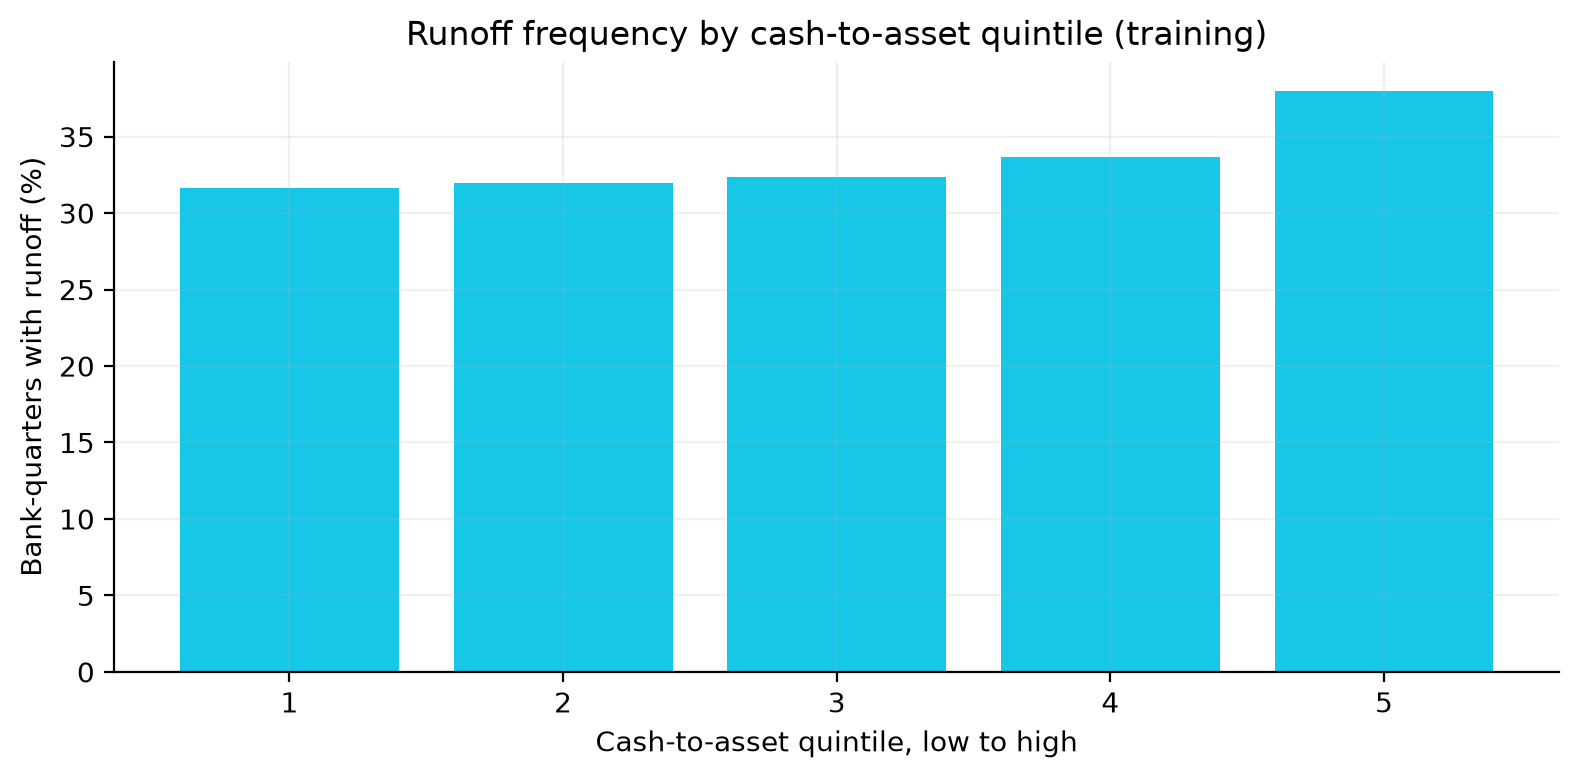

In [9]:
def add_features(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result["log_deposits"] = np.log1p(result.DEPDOM / 1_000)
    result["cash_to_assets"] = result.CHBAL / result.ASSET
    result["loans_to_assets"] = result.LNLSNET / result.ASSET
    result["equity_to_assets"] = result.EQ / result.ASSET
    previous_growth = (result.DEPDOM - result.prior_deposits) / result.prior_deposits
    result["prior_growth_asinh"] = np.arcsinh(previous_growth)
    result["calendar_quarter"] = result.report_date.dt.quarter
    return result

train, valid, test = (add_features(frame) for frame in (train, valid, test))
feature_columns = ["log_deposits", "cash_to_assets", "loans_to_assets",
                   "equity_to_assets", "prior_growth_asinh", "calendar_quarter"]
feature_receipt = pd.DataFrame({
    "predictor": feature_columns,
    "missing training rows": train[feature_columns].isna().sum().values,
    "median": train[feature_columns].median().round(3).values,
})
display(feature_receipt)

cash_quintile = pd.qcut(train.cash_to_assets, q=5, labels=False, duplicates="drop") + 1
cash_profile = train.assign(cash_quintile=cash_quintile).groupby("cash_quintile").agg(
    bank_rows=("CERT", "size"), runoff_banks=("runoff_m", lambda s: int(s.gt(0).sum())),
    median_cash_ratio=("cash_to_assets", "median"))
cash_profile["runoff_share"] = cash_profile.runoff_banks / cash_profile.bank_rows
display(cash_profile.round(3))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cash_profile.index.astype(str), cash_profile.runoff_share * 100, color=BLUE)
ax.set(title="Runoff frequency by cash-to-asset quintile (training)",
       xlabel="Cash-to-asset quintile, low to high", ylabel="Bank-quarters with runoff (%)")
plt.tight_layout()
plt.show()
takeaway_card(
    title="More cash did not mean fewer deposit declines in this sample",
    theme=theme,
    metric=(f"{cash_profile.runoff_share.iloc[0]:.1%} in the lowest cash quintile; "
            f"{cash_profile.runoff_share.iloc[-1]:.1%} in the highest"),
    body="This is an association across 2020–2022 bank-quarters. Bank type, size, and the period may explain it; the chart does not show that holding cash causes a decline.",
    kicker="EDA TAKEAWAY",
)

### 8. Do predictors repeat the same information?

Strong correlation does not automatically make a feature unusable. It does warn that an MLP may have redundant inputs. This matrix uses training rows only and keeps missing equity ratios out of each pairwise calculation.

,log_deposits,cash_to_assets,loans_to_assets,equity_to_assets,prior_growth_asinh,calendar_quarter
log_deposits,1.00,-0.18,0.19,-0.16,0.02,0.00
cash_to_assets,-0.18,1.00,-0.35,0.15,0.11,-0.05
loans_to_assets,0.19,-0.35,1.00,-0.04,-0.02,0.03
equity_to_assets,-0.16,0.15,-0.04,1.00,0.08,0.01
prior_growth_asinh,0.02,0.11,-0.02,0.08,1.00,-0.09
calendar_quarter,0.00,-0.05,0.03,0.01,-0.09,1.00


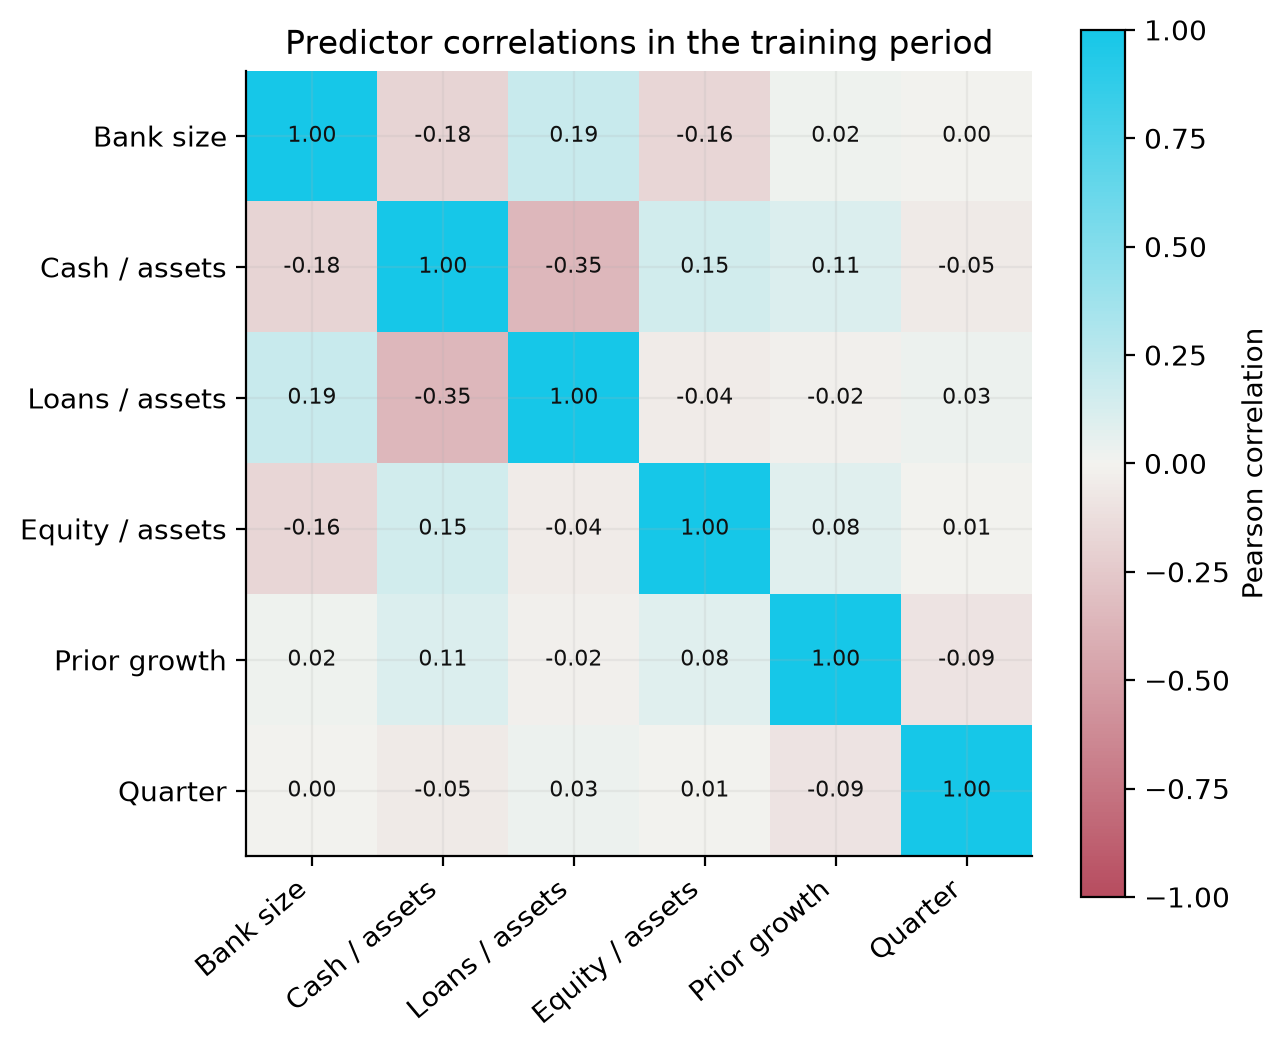

In [10]:
correlation = train[feature_columns].corr()
display(correlation.round(2))
fig, ax = plt.subplots(figsize=(6.5, 5.5))
from matplotlib.colors import LinearSegmentedColormap
labels = ["Bank size", "Cash / assets", "Loans / assets", "Equity / assets",
          "Prior growth", "Quarter"]
card_cmap = LinearSegmentedColormap.from_list("wm", [theme.heat_neg, theme.heat_mid, theme.heat_pos])
image = ax.imshow(correlation, vmin=-1, vmax=1, cmap=card_cmap)
ax.set_xticks(range(len(labels)), labels, rotation=40, ha="right")
ax.set_yticks(range(len(labels)), labels)
for row in range(len(feature_columns)):
    for col in range(len(feature_columns)):
        ax.text(col, row, f"{correlation.iloc[row, col]:.2f}", ha="center", va="center",
                color=INK, fontsize=8)
ax.set_title("Predictor correlations in the training period")
fig.colorbar(image, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

### EDA decision before modeling

The source supplies a large bank quarter panel with only limited missingness in the chosen financial fields. About one-third of training rows have any decline, while positive declines span a long dollar tail. That suggests two related predictions: **chance of a decline** and **size conditional on a decline**. The network receives log domestic deposits; the severity head learns `log1p(runoff in $M)` on positive rows only. Missing predictor values receive a median fitted on training rows alone. I keep the original CSV unchanged. The reported balance change can be affected by bank structure changes, and the matched panel excludes banks without an adjacent next report.

The chart inventory has a job for each view: quarter coverage (time), missingness (quality), deposit and runoff histograms (shape), frequency and dollars over time (target), a cash ratio comparison (relationship), and a correlation matrix (redundancy). A map would add no evidence to this bank level forecasting question, so I omit it.

## Method | Chance, severity, and a review priority

**Architecture.** Six standardized financial predictors enter two shared ReLU layers (32 then 16 units). One output uses sigmoid to estimate the chance of any next-quarter deposit decline. The other uses softplus to estimate `log1p(positive runoff $M)`. The severity loss receives weight only for rows where a decline occurred. A simple one-output MLP provides a comparison with direct dollar prediction.

**Why two heads?** A direct MAE regression can learn to predict almost zero for everyone when most rows have no decline. Separating occurrence from size gives the network a reason to recognize the declines before estimating their scale. I compare it with simple rules: the training-period decline rate, predicting no decline, and repeating last quarter's decline. Validation controls early stopping; 2024 remains the held-out test.

**A careful combined score.** I multiply predicted probability by predicted conditional *typical* decline in dollars to rank banks for review. Because the severity head learns a log-scale median, this product is a **priority score in dollar units**, not a calibrated expected loss. It cannot justify a liquidity reserve without further calibration.

**Implementation contract.** The imputer and scaler fit on training predictors only. `expm1` reverses the severity transform for dollar comparisons. Random seeds make the comparison repeatable. The small tabular network runs on CPU so the notebook can run without school GPU access.

In [11]:
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
X_train = scaler.fit_transform(imputer.fit_transform(train[feature_columns])).astype("float32")
X_valid = scaler.transform(imputer.transform(valid[feature_columns])).astype("float32")
X_test = scaler.transform(imputer.transform(test[feature_columns])).astype("float32")
y_train_log = np.log1p(train.runoff_m.to_numpy()).astype("float32")
y_valid_log = np.log1p(valid.runoff_m.to_numpy()).astype("float32")
y_train_fell = train.runoff_m.gt(0).to_numpy(dtype="float32")
y_valid_fell = valid.runoff_m.gt(0).to_numpy(dtype="float32")
assert np.isfinite(X_train).all() and np.isfinite(X_valid).all() and np.isfinite(X_test).all()
print("Prepared matrices:", X_train.shape, X_valid.shape, X_test.shape)

Prepared matrices: (53121, 6) (18321, 6) (13480, 6)


In [12]:
# A direct one-output network is a useful comparison for a zero-heavy target.
tf.keras.utils.set_random_seed(SEED)
single_input = tf.keras.Input(shape=(len(feature_columns),))
single_hidden = tf.keras.layers.Dense(32, activation="relu")(single_input)
single_hidden = tf.keras.layers.Dense(16, activation="relu")(single_hidden)
single_output = tf.keras.layers.Dense(1, activation="softplus")(single_hidden)
single_model = tf.keras.Model(single_input, single_output, name="single_output")
single_model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss="mae")
single_history = single_model.fit(
    X_train, y_train_log, validation_data=(X_valid, y_valid_log),
    epochs=20, batch_size=256, verbose=0,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True)],
)

# Two ordinary Keras output layers share the same bank representation.
tf.keras.utils.set_random_seed(SEED)
bank_input = tf.keras.Input(shape=(len(feature_columns),), name="bank_financials")
hidden = tf.keras.layers.Dense(32, activation="relu")(bank_input)
hidden = tf.keras.layers.Dense(16, activation="relu")(hidden)
chance_output = tf.keras.layers.Dense(1, activation="sigmoid", name="decline_chance")(hidden)
severity_output = tf.keras.layers.Dense(1, activation="softplus", name="severity_log")(hidden)
two_head_model = tf.keras.Model(
    bank_input, {"decline_chance": chance_output, "severity_log": severity_output}, name="two_head")
two_head_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss={"decline_chance": "binary_crossentropy", "severity_log": "mae"},
    loss_weights={"decline_chance": 1.0, "severity_log": 0.2},
    run_eagerly=True,  # Avoid an intermittent compiled Adam shape error on this Mac.
)
train_targets = {"decline_chance": y_train_fell, "severity_log": y_train_log}
valid_targets = {"decline_chance": y_valid_fell, "severity_log": y_valid_log}
train_weights = {"decline_chance": np.ones_like(y_train_fell),
                 "severity_log": y_train_fell}
valid_weights = {"decline_chance": np.ones_like(y_valid_fell),
                 "severity_log": y_valid_fell}
two_head_history = two_head_model.fit(
    X_train, train_targets, sample_weight=train_weights,
    validation_data=(X_valid, valid_targets, valid_weights),
    epochs=20, batch_size=256, verbose=0,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True)],
)
print(f"Single-output network: {len(single_history.history['loss'])} epochs")
print(f"Two-head network: {len(two_head_history.history['loss'])} epochs")

Single-output network: 4 epochs
Two-head network: 8 epochs


## Experiments | Does splitting the question help?

The training curves show when 2023 validation error stops improving. The losses have different meanings, so their heights should not be compared across panels. We evaluate probability with **Brier score** (lower is better) and ROC AUC (higher is better), positive-decline severity with **MAE in $M**, and the review list with the share of observed decline dollars captured among the top 10% of bank quarters.

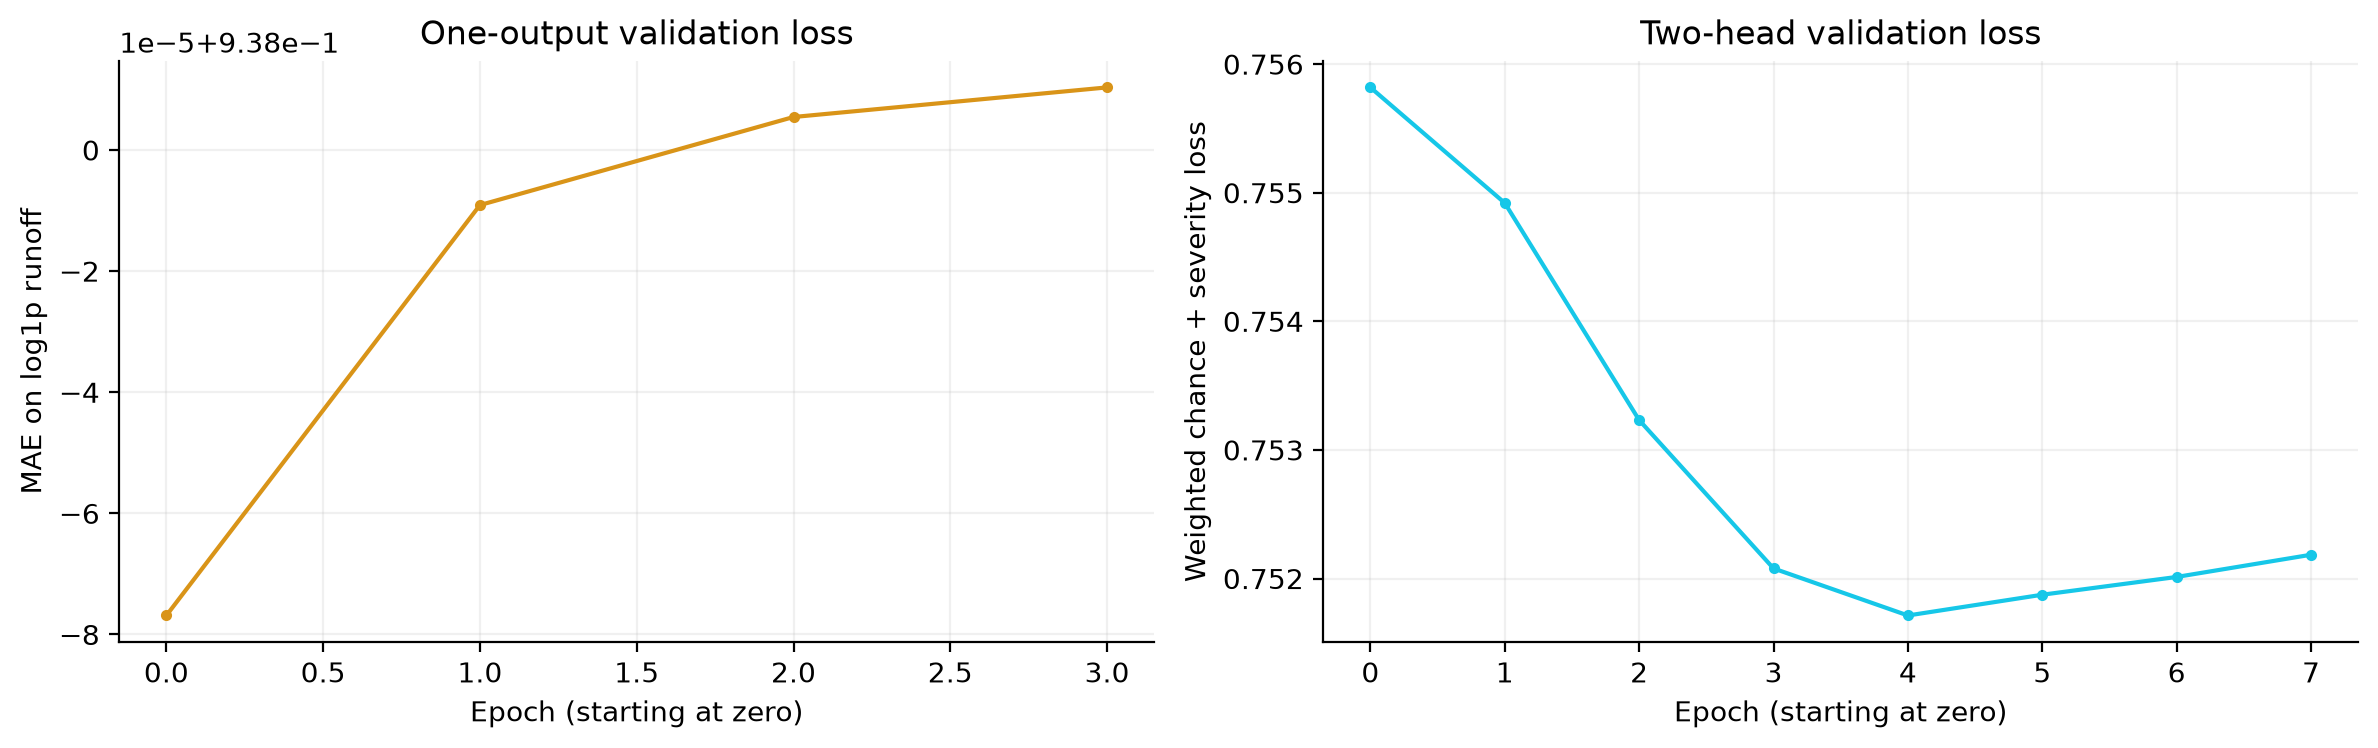

,Brier score,ROC AUC
Training decline rate,0.262,0.500
Last-quarter direction,0.486,0.512
Two-head chance,0.248,0.608


,Conditional MAE ($M)
Training positive median,64.7
Repeat last decline,60.8
Two-head severity,246.1


,Decline cases in top 10%,Observed runoff dollars in top 10%
Current deposits,8.8%,85.7%
Repeat last decline,9.7%,47.4%
Chance head alone,12.9%,47.8%
One-output MLP,12.1%,1.9%
Two-head priority,9.2%,86.3%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(single_history.history["val_loss"], marker="o", ms=3, color=GOLD)
axes[0].set(title="One-output validation loss", xlabel="Epoch (starting at zero)",
            ylabel="MAE on log1p runoff")
axes[1].plot(two_head_history.history["val_loss"], marker="o", ms=3, color=BLUE)
axes[1].set(title="Two-head validation loss", xlabel="Epoch (starting at zero)",
            ylabel="Weighted chance + severity loss")
plt.tight_layout()
plt.show()

def predict_two_heads(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    predictions = two_head_model.predict(matrix, batch_size=1024, verbose=0)
    chance = predictions["decline_chance"].ravel()
    log_severity = predictions["severity_log"].ravel()
    return chance, np.expm1(log_severity).clip(min=0)

def top_decile_coverage(actual: np.ndarray, priority: np.ndarray) -> float:
    if np.all(priority == priority[0]):
        return np.nan  # A constant score cannot rank bank quarters.
    take = max(1, int(np.ceil(len(priority) * 0.10)))
    top_rows = np.argsort(priority)[-take:]
    return actual[top_rows].sum() / actual.sum() if actual.sum() else np.nan

def top_decile_case_recall(actual: np.ndarray, priority: np.ndarray) -> float:
    if np.all(priority == priority[0]):
        return np.nan
    take = max(1, int(np.ceil(len(priority) * 0.10)))
    top_rows = np.argsort(priority)[-take:]
    return np.count_nonzero(actual[top_rows] > 0) / np.count_nonzero(actual > 0)

valid_actual = valid.runoff_m.to_numpy()
valid_fell = valid_actual > 0
valid_prior_decline = ((valid.prior_deposits - valid.DEPDOM) / 1_000).clip(lower=0).to_numpy()
valid_single = np.expm1(single_model.predict(X_valid, batch_size=1024, verbose=0).ravel()).clip(min=0)
valid_chance, valid_severity = predict_two_heads(X_valid)
valid_priority = valid_chance * valid_severity

chance_receipt = pd.DataFrame({
    "Brier score": [brier_score_loss(valid_fell, np.full(len(valid), y_train_fell.mean())),
                    brier_score_loss(valid_fell, (valid_prior_decline > 0).astype(float)),
                    brier_score_loss(valid_fell, valid_chance)],
    "ROC AUC": [0.5, roc_auc_score(valid_fell, valid_prior_decline > 0),
                roc_auc_score(valid_fell, valid_chance)],
}, index=["Training decline rate", "Last-quarter direction", "Two-head chance"])
display(chance_receipt.round(3))

positive_valid = valid_fell
severity_receipt = pd.DataFrame({
    "Conditional MAE ($M)": [
        mean_absolute_error(valid_actual[positive_valid],
                            np.full(positive_valid.sum(), train.loc[train.runoff_m.gt(0), "runoff_m"].median())),
        mean_absolute_error(valid_actual[positive_valid], valid_prior_decline[positive_valid]),
        mean_absolute_error(valid_actual[positive_valid], valid_severity[positive_valid]),
    ],
}, index=["Training positive median", "Repeat last decline", "Two-head severity"])
display(severity_receipt.round(1))

valid_rank_receipt = pd.DataFrame({
    "Decline cases in top 10%": [
        top_decile_case_recall(valid_actual, valid.DEPDOM.to_numpy()),
        top_decile_case_recall(valid_actual, valid_prior_decline),
        top_decile_case_recall(valid_actual, valid_chance),
        top_decile_case_recall(valid_actual, valid_single),
        top_decile_case_recall(valid_actual, valid_priority),
    ],
    "Observed runoff dollars in top 10%": [
        top_decile_coverage(valid_actual, valid.DEPDOM.to_numpy()),
        top_decile_coverage(valid_actual, valid_prior_decline),
        top_decile_coverage(valid_actual, valid_chance),
        top_decile_coverage(valid_actual, valid_single),
        top_decile_coverage(valid_actual, valid_priority),
    ],
}, index=["Current deposits", "Repeat last decline", "Chance head alone",
          "One-output MLP", "Two-head priority"])
display(valid_rank_receipt.style.format("{:.1%}"))

### The sealed 2024 answer

The test covers 2024 Q1–Q3 current reports and their next quarter balances. It asks three separate questions: did the chance head distinguish declines, did the severity head estimate positive declines, and did the combined priority score put observed runoff dollars near the top of a finite review list? The top-10% measure is **ranking coverage**, not money saved. The all-row MAE compares a dollar-sized priority proxy with realized balances as a scale check; the proxy is not a calibrated expected loss.

,Brier score,ROC AUC
Training decline rate,0.244,0.500
Last-quarter direction,0.496,0.486
Two-head chance,0.236,0.591


,Conditional MAE ($M)
Training positive median,76.7
Repeat last decline,77.5
Two-head severity,74.3


,All-row MAE ($M),Decline cases in top 10%,Runoff dollars in top 10%
Current deposits,—,9.3%,89.0%
Repeat last decline,$51.4,8.6%,27.2%
Chance head alone,—,12.7%,39.6%
One-output MLP,$31.4,10.6%,1.2%
Two-head priority,$45.5,9.6%,89.4%
Zero decline,$31.4,—,—


Observed 2024 test runoff: $423.0B across 13,480 bank quarters; 5,390 had a decline.


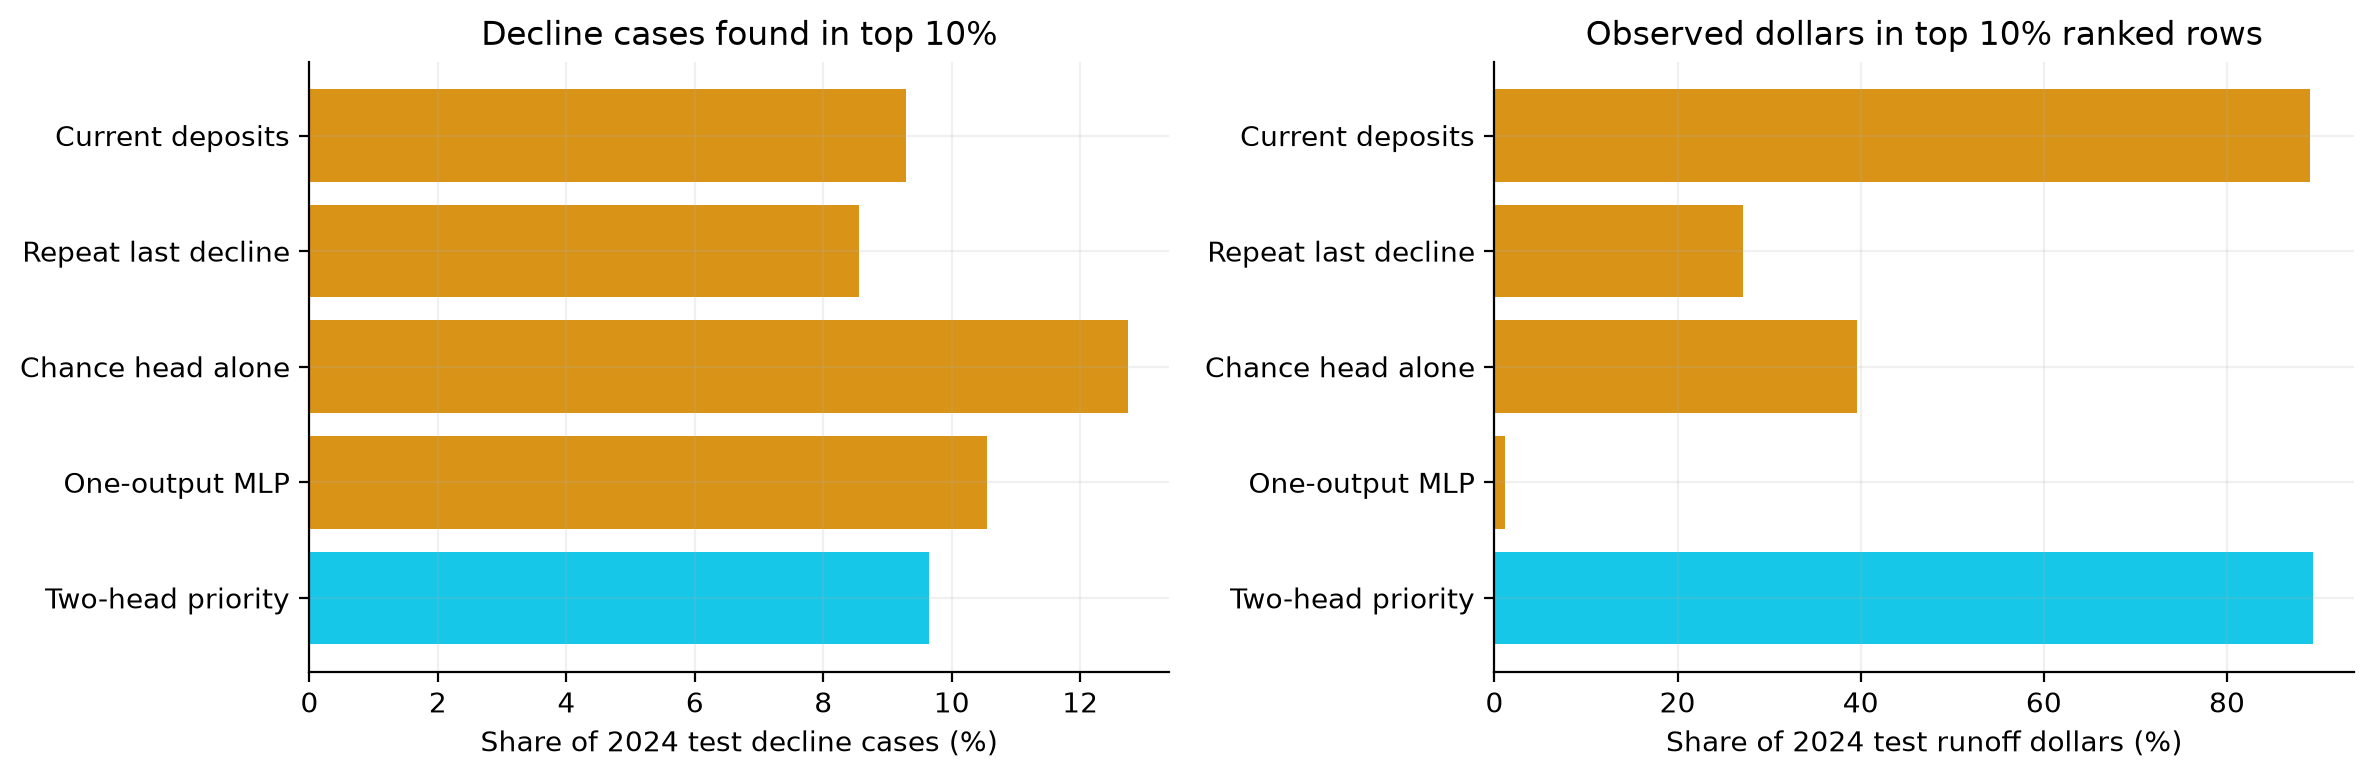

In [14]:
test_actual = test.runoff_m.to_numpy()
test_fell = test_actual > 0
test_prior_decline = ((test.prior_deposits - test.DEPDOM) / 1_000).clip(lower=0).to_numpy()
test_single = np.expm1(single_model.predict(X_test, batch_size=1024, verbose=0).ravel()).clip(min=0)
test_chance, test_severity = predict_two_heads(X_test)
test_priority = test_chance * test_severity

test_chance_receipt = pd.DataFrame({
    "Brier score": [brier_score_loss(test_fell, np.full(len(test), y_train_fell.mean())),
                    brier_score_loss(test_fell, (test_prior_decline > 0).astype(float)),
                    brier_score_loss(test_fell, test_chance)],
    "ROC AUC": [0.5, roc_auc_score(test_fell, test_prior_decline > 0),
                roc_auc_score(test_fell, test_chance)],
}, index=["Training decline rate", "Last-quarter direction", "Two-head chance"])
display(test_chance_receipt.round(3))

test_severity_receipt = pd.DataFrame({
    "Conditional MAE ($M)": [
        mean_absolute_error(test_actual[test_fell],
                            np.full(test_fell.sum(), train.loc[train.runoff_m.gt(0), "runoff_m"].median())),
        mean_absolute_error(test_actual[test_fell], test_prior_decline[test_fell]),
        mean_absolute_error(test_actual[test_fell], test_severity[test_fell]),
    ],
}, index=["Training positive median", "Repeat last decline", "Two-head severity"])
display(test_severity_receipt.round(1))

test_priorities = {"Current deposits": test.DEPDOM.to_numpy(),
                   "Repeat last decline": test_prior_decline,
                   "Chance head alone": test_chance,
                   "One-output MLP": test_single,
                   "Two-head priority": test_priority}
test_scores = pd.DataFrame({
    name: {"Decline cases in top 10%": top_decile_case_recall(test_actual, prediction),
           "Runoff dollars in top 10%": top_decile_coverage(test_actual, prediction)}
    for name, prediction in test_priorities.items()
}).T
for name in ("Repeat last decline", "One-output MLP", "Two-head priority"):
    test_scores.loc[name, "All-row MAE ($M)"] = mean_absolute_error(
        test_actual, test_priorities[name])
test_scores.loc["Zero decline", "All-row MAE ($M)"] = mean_absolute_error(test_actual, np.zeros(len(test)))
test_scores = test_scores[["All-row MAE ($M)", "Decline cases in top 10%",
                           "Runoff dollars in top 10%"]]
wm_render_styler(
    test_scores.style.format({"All-row MAE ($M)": "${:,.1f}",
                              "Decline cases in top 10%": "{:.1%}",
                              "Runoff dollars in top 10%": "{:.1%}"}, na_rep="—"),
    theme=theme,
    title="2024 holdout: dollar error and watchlist coverage",
    subtitle="MAE is a dollar-scale check; coverage uses the top-ranked 10%.",
    kicker="TEST RESULT",
)
print(f"Observed 2024 test runoff: ${test_actual.sum()/1_000:,.1f}B across "
      f"{len(test):,} bank quarters; {np.count_nonzero(test_actual):,} had a decline.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rank_plot = test_scores.drop(index="Zero decline")
plot_colors = [BLUE if name == "Two-head priority" else GOLD
               for name in rank_plot.index[::-1]]
axes[0].barh(rank_plot.index[::-1],
             100 * rank_plot["Decline cases in top 10%"].values[::-1],
             color=plot_colors)
axes[0].set(title="Decline cases found in top 10%", xlabel="Share of 2024 test decline cases (%)")
axes[1].barh(rank_plot.index[::-1],
             100 * rank_plot["Runoff dollars in top 10%"].values[::-1],
             color=plot_colors)
axes[1].set(title="Observed dollars in top 10% ranked rows",
            xlabel="Share of 2024 test runoff dollars (%)")
plt.tight_layout()
plt.show()
capture = test_scores.loc["Two-head priority", "Runoff dollars in top 10%"]
size_capture = test_scores.loc["Current deposits", "Runoff dollars in top 10%"]
chance_case_capture = test_scores.loc["Chance head alone", "Decline cases in top 10%"]
size_case_capture = test_scores.loc["Current deposits", "Decline cases in top 10%"]
priority_mae = test_scores.loc["Two-head priority", "All-row MAE ($M)"]
zero_mae = test_scores.loc["Zero decline", "All-row MAE ($M)"]
chance_auc = test_chance_receipt.loc["Two-head chance", "ROC AUC"]
takeaway_card(
    title="Bank size explains much of the dollar-ranked result",
    theme=theme,
    metric=f"{capture:.1%} of observed decline dollars in the top-ranked 10%",
    body=(f"Current deposits alone covered {size_capture:.1%} of dollars. The chance-only "
          f"list found {chance_case_capture:.1%} of decline cases versus {size_case_capture:.1%} "
          f"for size; chance ROC AUC was {chance_auc:.3f}. Dollar MAE was ${priority_mae:,.1f}M "
          f"versus ${zero_mae:,.1f}M for predicting no decline. Stronger evidence is needed."),
    kicker="BUSINESS TAKEAWAY",
)

### Are the predicted probabilities believable?

The 2024 test rows are grouped into ten equal-sized bands of **predicted** decline probability. In each band, the chart compares average prediction with the share that actually declined. Points near the diagonal are better calibrated. This is a diagnostic on one held-out year, not a guarantee that the probabilities will stay calibrated later.

,bank_quarters,mean_probability,observed_decline_share
0,1348,0.224,0.279
1,1348,0.273,0.308
2,1348,0.302,0.336
3,1348,0.326,0.367
4,1348,0.349,0.367
5,1348,0.374,0.416
6,1348,0.402,0.459
7,1348,0.434,0.459
8,1348,0.471,0.497
9,1348,0.542,0.510


Weighted average calibration gap across these bands: 3.7%


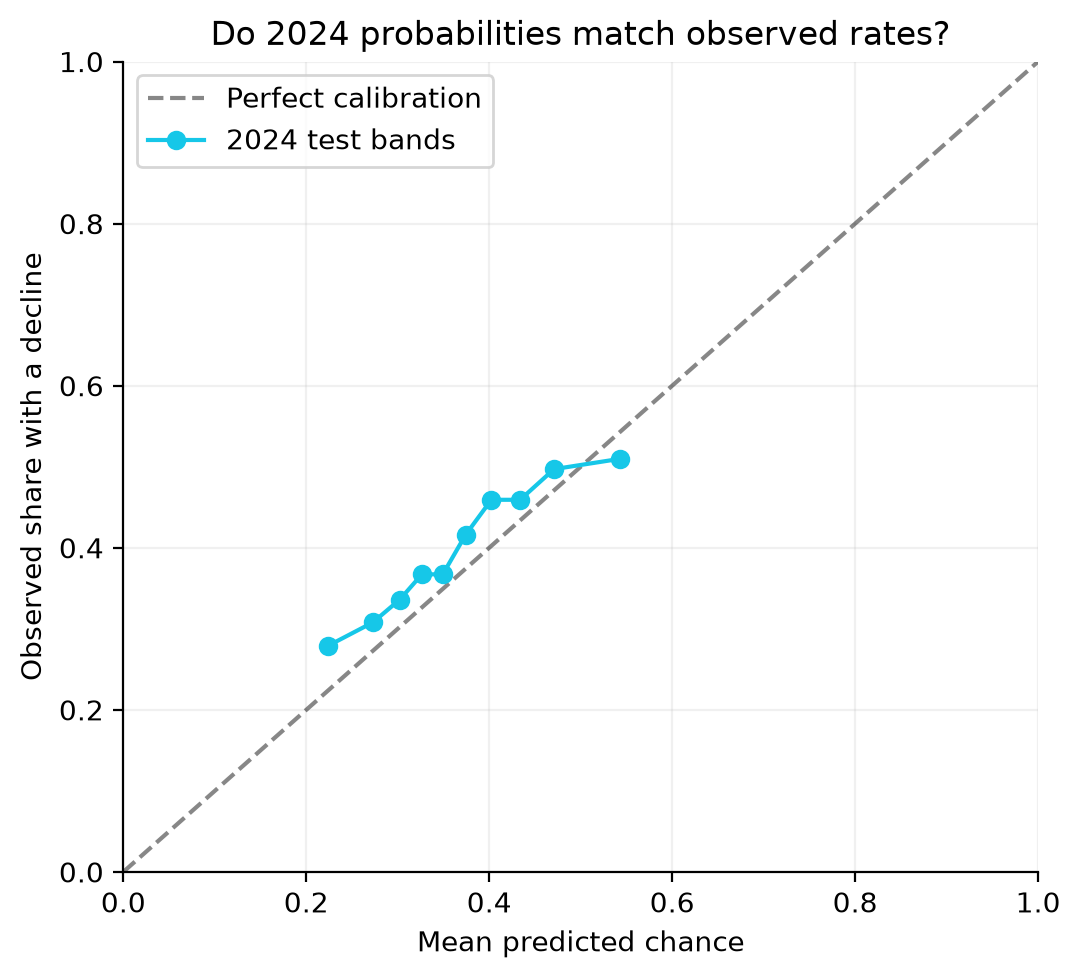

In [15]:
calibration_rows = pd.DataFrame({"predicted": test_chance, "declined": test_fell})
calibration_rows["band"] = pd.qcut(calibration_rows.predicted, q=10, duplicates="drop")
calibration_receipt = calibration_rows.groupby("band", observed=True).agg(
    bank_quarters=("declined", "size"),
    mean_probability=("predicted", "mean"),
    observed_decline_share=("declined", "mean"),
).reset_index(drop=True)
display(calibration_receipt.round(3))
calibration_gap = np.average(
    np.abs(calibration_receipt.mean_probability - calibration_receipt.observed_decline_share),
    weights=calibration_receipt.bank_quarters,
)
print(f"Weighted average calibration gap across these bands: {calibration_gap:.1%}")
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot([0, 1], [0, 1], color=INK, linestyle="--", alpha=.5, label="Perfect calibration")
ax.plot(calibration_receipt.mean_probability, calibration_receipt.observed_decline_share,
        color=BLUE, marker="o", label="2024 test bands")
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Mean predicted chance",
       ylabel="Observed share with a decline", title="Do 2024 probabilities match observed rates?")
ax.legend()
plt.tight_layout()
plt.show()

### Which banks would appear on the watchlist?

This example ranks banks in the **latest test quarter, 2024 Q3**. The top ten are a display size, not an operational cutoff. Probability and conditional severity remain separate; the product only sorts the list. The last column names the input whose replacement with its training median most reduced that bank's **predicted chance**. It describes **model sensitivity**, not the real cause of a deposit change.

In [16]:
latest_quarter = test.report_date.max()
latest_rows = np.flatnonzero(test.report_date.eq(latest_quarter).to_numpy())
ranked_latest = latest_rows[np.argsort(test_priority[latest_rows])[::-1]]
watch_positions = ranked_latest[:10]

# One-feature-at-a-time median replacement is a readable sensitivity check.
median_raw = train[feature_columns].median().to_frame().T
median_scaled = scaler.transform(imputer.transform(median_raw))[0]
cue_changes = []
for column_number in range(len(feature_columns)):
    changed = X_test[watch_positions].copy()
    changed[:, column_number] = median_scaled[column_number]
    changed_chance, _ = predict_two_heads(changed)
    cue_changes.append(test_chance[watch_positions] - changed_chance)
cue_changes = np.column_stack(cue_changes)
cue_names = np.array(["Bank size", "Cash / assets", "Loans / assets",
                      "Equity / assets", "Prior growth", "Calendar quarter"])
strongest = cue_changes.argmax(axis=1)
model_cues = np.where(cue_changes.max(axis=1) > 0,
                      cue_names[strongest], "No single positive median comparison")

watchlist = test.iloc[watch_positions][["NAME", "CERT", "DEPDOM"]].copy()
watchlist["Chance of decline"] = test_chance[watch_positions]
watchlist["Typical decline if it falls ($M)"] = test_severity[watch_positions]
watchlist["Priority score ($M)"] = test_priority[watch_positions]
watchlist["Chance cue"] = model_cues
watchlist["Current deposits ($M)"] = watchlist.pop("DEPDOM") / 1_000
watchlist = watchlist.rename(columns={"NAME": "Bank", "CERT": "Certificate"})
watchlist = watchlist[["Bank", "Certificate", "Current deposits ($M)",
                       "Chance of decline", "Typical decline if it falls ($M)",
                       "Priority score ($M)", "Chance cue"]].reset_index(drop=True)
watchlist.index = np.arange(1, len(watchlist) + 1)
watchlist.index.name = "Review order"
wm_render_styler(
    watchlist.style.format({"Current deposits ($M)": "${:,.0f}",
                            "Chance of decline": "{:.0%}",
                            "Typical decline if it falls ($M)": "${:,.1f}",
                            "Priority score ($M)": "${:,.1f}"}),
    theme=theme,
    title=f"Watchlist from the {latest_quarter:%Y-%m-%d} report",
    subtitle="Ranked by probability × typical positive decline; 10 rows shown.",
    kicker="REVIEW FIRST",
    wrap_columns={"Bank": 220, "Chance cue": 220},
)
print(f"After the fact: these ten banks had ${test_actual[watch_positions].sum():,.1f}M "
      "in observed next-quarter deposit declines.")

,Bank,Certificate,Current deposits ($M),Chance of decline,Typical decline if it falls ($M),Priority score ($M),Chance cue
Review order,,,,,,,
1,JPMORGAN CHASE BANK NA,628,"$2,032,340",53%,"$61,039.8","$32,243.3",Bank size
2,BANK OF AMERICA NA,3510,"$1,892,511",54%,"$58,516.0","$31,607.4",Bank size
3,WELLS FARGO BANK NA,3511,"$1,397,345",50%,"$43,395.4","$21,817.2",Bank size
4,CITIBANK NATIONAL ASSN,7213,"$766,194",41%,"$22,692.2","$9,325.7",Bank size
5,U S BANK NATIONAL ASSN,6548,"$522,482",50%,"$15,532.1","$7,692.9",Bank size
6,PNC BANK NATIONAL ASSN,6384,"$429,849",46%,"$11,304.5","$5,246.3",Bank size
7,TRUIST BANK,9846,"$400,419",43%,"$10,487.6","$4,458.1",Bank size
8,CAPITAL ONE NATIONAL ASSN,4297,"$379,886",39%,"$10,332.4","$4,036.2",Bank size
9,GOLDMAN SACHS BANK USA,33124,"$370,460",34%,"$10,404.4","$3,580.9",Bank size


After the fact: these ten banks had $9,161.9M in observed next-quarter deposit declines.


## Overall experiments | Conclusion and lessons learned

**Answer to the business question: not convincingly yet.** The 2024 Q3 watchlist shows each bank's predicted chance of a decline, typical decline if it happens, and review priority. In the 2024 holdout, the chance-only ranking found **12.7% of actual decline cases** in its top 10% of bank-quarters, compared with **9.3%** from ranking by bank size. The two-head dollar priority captured **89.4% of observed runoff dollars**, but bank size alone captured **89.0%**. Its dollar-sized priority score had **$45.5 million** all-row MAE, compared with **$31.4 million** for predicting no decline. The model adds a modest chance signal, while its dollar ranking largely rediscovers big banks. It is an interpretable prototype, not an operational early-warning system.

**Difficulties encountered.** Defining the outcome required matching adjacent reports for the same FDIC certificate, converting amounts from thousands to millions of dollars, and excluding banks without an observed next report. About two-thirds of training bank-quarters had no decline, while the largest positive decline was **$76.7 billion**. That mix let the one-output MAE model settle near zero. The two-head model needed its severity loss applied only to rows with a decline; its conditional dollar MAE was **$246.1 million on validation** versus **$64.7 million** for the positive-median rule, showing how unstable that estimate can be. Finally, a high dollar-capture result looked impressive until the simple bank-size baseline exposed how much of it came from scale.

**Lessons learned and next step.** Separating probability, conditional severity, and ranking made the weaknesses visible: the 2024 chance head reached **0.591 ROC AUC**, and its probabilities still need monitoring for calibration. A treasury team would set review capacity or a cost-based threshold after seeing these results; no 0.50 cutoff is imposed here. The next study should add bank structure events and funding measures, then retest on later quarters. FDIC balance changes do not reveal customer withdrawals or explain why a bank's deposits changed; the watchlist remains a prompt for human investigation.

## References

Federal Deposit Insurance Corporation. (n.d.). *BankFind Suite: API documentation.* https://api.fdic.gov/banks/docs/

Federal Deposit Insurance Corporation. (n.d.). *Financial API field definitions.* https://api.fdic.gov/banks/docs/risview_properties.yaml

TensorFlow. (n.d.). *Keras API documentation.* https://www.tensorflow.org/api_docs/python/tf/keras